In [1]:
from langgraph.graph import StateGraph, START, END
from typing import Annotated, TypedDict
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openrouter import ChatOpenRouter
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver

C:\Users\user pc\PycharmProjects\LangGraph_Practice\.venv\Lib\site-packages\langchain_core\utils\pydantic.py:42: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1


In [2]:
load_dotenv()

True

In [3]:
llm = ChatOpenRouter(
    model="inclusionai/ling-3.0-flash-vl:free",
    temperature=0
)

In [4]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [5]:
def chat_node(state: ChatState):
    message = state["messages"]

    response = llm.invoke(message).content

    return {
        "messages": [response]
    }

In [6]:
checkpoint = MemorySaver()
graph = StateGraph(ChatState)

graph.add_node("chat_node", chat_node)

graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

chatbot = graph.compile(checkpointer=checkpoint)

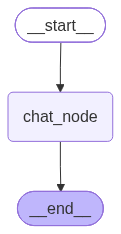

In [7]:
chatbot

In [8]:
thread_id = 2
initial_state = {
    "messages": [HumanMessage(content="What is my name? ")]
}

config = {
    "configurable": {"thread_id": thread_id}
}
response = chatbot.invoke(initial_state, config=config)

In [9]:
response['messages'][-1].content

"I'm sorry, but I don't have any information about your name. I don't have access to personal data about users unless you share it with me during our conversation. If you'd like, feel free to tell me your name, and I'll be happy to use it! 😊"

In [10]:
thread_id = 1
while True:
    user_input = input("Enter you query: ")
    user_input.lower()
    if user_input in ["quit", "exit"]:
        break
    config = {
        "configurable": {"thread_id": thread_id}
    }
    response = chatbot.invoke({
        "messages": [HumanMessage(content=user_input)]
    }, config=config)
    print('AI:', response['messages'][-1].content)


TooManyRequestsResponseError: Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day

In [11]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='Hi what is my name?', additional_kwargs={}, response_metadata={}, id='224e2db6-6b10-4ec4-897c-5d284cd31ead')]}, next=('chat_node',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b52bc-efdb-69e8-8000-5cd20de5f15f'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-09-20T19:45:18.615159+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b52bc-efd2-6b88-bfff-adf8db9b3f22'}}, tasks=(PregelTask(id='25057953-d0a6-ca55-3989-60434292f084', name='chat_node', path=('__pregel_pull', 'chat_node'), error=None, interrupts=(), state=None, result=None),), interrupts=())